# Actividad Práctica U2
## Proyecto: Análisis de sentimiento y tendencias en redes sociales
### Fase 1: Extracción y tratamiento de datos

In [1]:
from data_extractor import DataExtractor

## 1) Carga de datos, almacenamiento y análisis inicial

In [2]:
file_path = "data/Bitcoin_tweets_dataset_2.csv"
extractor = DataExtractor(file_path)
df = extractor.load_data()
df.head()

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,ChefSam,Sunshine State,Culinarian | Hot Sauce Artisan | Kombucha Brew...,2011-03-23 03:50:13,4680.0,2643.0,6232,False,2023-03-01 23:59:59,Which #bitcoin books should I think about read...,['bitcoin'],Twitter for iPhone,False
1,Roy⚡️,NaN,Truth-seeking pleb 📚 • Science 🧪 • Nature 🌱☀️ ...,2022-01-30 17:41:41,770.0,1145.0,9166,False,2023-03-01 23:59:47,"@ThankGodForBTC I appreciate the message, but ...",['Bitcoin'],Twitter for iPhone,False
2,Ethereum Yoda,NaN,UP or DOWN...\n.\n.\n.\n.\nPrice matters NOT.,2022-07-24 04:50:18,576.0,1.0,0,False,2023-03-01 23:59:42,#Ethereum price update: \n\n#ETH $1664.02 USD\...,"['Ethereum', 'ETH', 'Bitcoin', 'BTC', 'altcoin...",Twitter Web App,False
3,Viction,"Paris, France",https://t.co/8M3rgdjwEe\n\n#bitcoin #blockchai...,2010-03-26 10:15:26,236.0,1829.0,2195,False,2023-03-01 23:59:36,CoinDashboard v3.0 is here\nAvailable on ios a...,['Bitcoin'],Twitter for Android,False
4,Rosie,London,"The flower language of jasmine is loyalty, res...",2013-02-16 09:57:56,12731.0,46.0,134,False,2023-03-01 23:59:32,#Bitcoin Short Term Fractal (4H)💥\n\nIn lower ...,"['Bitcoin', 'BTC']",Twitter Web App,False


## 2) Limpieza y normalización de texto

In [3]:
for i, row in df.iterrows():
    text_test = row.get("text", "")
    cleaned_text = extractor.clean_text(text_test)
    print(f"{i}. Original: {text_test}\nLimpio: {cleaned_text}\n")
    if i >= 9:  # Limitar a las primeras 10 filas para evitar demasiada salida
        break

0. Original: Which #bitcoin books should I think about reading next? https://t.co/32gas26rKB
Limpio: which #bitcoin books should i think about reading next

1. Original: @ThankGodForBTC I appreciate the message, but not a fan of the religious references. Religion has nothing to do with #Bitcoin.
Limpio: i appreciate the message but not a fan of the religious references religion has nothing to do with #bitcoin

2. Original: #Ethereum price update: 

#ETH $1664.02 USD
#Bitcoin 0.070428 #BTC

Follow for recent ETH price updates
#altcoin, #cryptocurrency, #crypto
Limpio: #ethereum price update #eth 166402 usd #bitcoin 0070428 #btc follow for recent eth price updates #altcoin #cryptocurrency #crypto

3. Original: CoinDashboard v3.0 is here
Available on ios and Android
#Bitcoin https://t.co/tMCQllv9rj
Limpio: coindashboard v30 is here available on ios and android #bitcoin

4. Original: #Bitcoin Short Term Fractal (4H)💥

In lower timeframe, #BTC price action seems to be repeating itself while

## 3) Análisis básico - Extracción de hashtags

In [4]:
for i, row in df.iterrows():
    text_test = row.get("text", "")
    text_hashtags = extractor.extract_hashtags(text_test)
    print(f"{i}. Texto: {text_test}\nHashtags: {text_hashtags}\n")
    if i > 9:  # Limitar a las primeras 10 filas para evitar demasiada salida
        break

0. Texto: Which #bitcoin books should I think about reading next? https://t.co/32gas26rKB
Hashtags: ['#bitcoin']

1. Texto: @ThankGodForBTC I appreciate the message, but not a fan of the religious references. Religion has nothing to do with #Bitcoin.
Hashtags: ['#Bitcoin']

2. Texto: #Ethereum price update: 

#ETH $1664.02 USD
#Bitcoin 0.070428 #BTC

Follow for recent ETH price updates
#altcoin, #cryptocurrency, #crypto
Hashtags: ['#Ethereum', '#ETH', '#Bitcoin', '#BTC', '#altcoin', '#cryptocurrency', '#crypto']

3. Texto: CoinDashboard v3.0 is here
Available on ios and Android
#Bitcoin https://t.co/tMCQllv9rj
Hashtags: ['#Bitcoin']

4. Texto: #Bitcoin Short Term Fractal (4H)💥

In lower timeframe, #BTC price action seems to be repeating itself while LMACD is reproducing the same sequence. 🫡 https://t.co/2MG9yL7SDa
Hashtags: ['#Bitcoin', '#BTC']

5. Texto: Y’all Message me for any account recovery or hacking #CYBER #security #Coinbase #Bitcoin #BNB #facebook #snapchat #instagram.
Hashta

## 4) Análisis avanzado - Tendencias de hashtags

In [5]:
extractor = DataExtractor(file_path)
extractor.load_data()
hashtag_analysis = extractor.analytics_hashtags_extended()

In [6]:
hashtag_analysis['overall'].head()

,hashtag,frequency
0,#bitcoin,154528
1,#btc,66594
2,#crypto,62556
3,#cryptocurrency,34543
4,#eth,33052


In [7]:
hashtag_analysis['by_user'].head()

,user_name,hashtag,frequency
0,! Nett SOL,#blockchain,2
1,! Nett SOL,#btc,2
2,! Nett SOL,#crypto,3
3,! Nett SOL,#cryptocurrencymarket,1
4,! Nett SOL,#decentralized,2


In [8]:
hashtag_analysis['by_date'].head()

,date,hashtag,frequency
0,2023-02-25,#1,8
1,2023-02-25,#10000x,1
2,2023-02-25,#1000x,1
3,2023-02-25,#1000xgem,2
4,2023-02-25,#100daysofcode,5


In [9]:
hashtag_analysis['keywords_overall'].head(20)

,keyword,frequency
0,price,46745
1,btc,28610
2,you,22176
3,follow,18707
4,usd,18353
5,eth,18166
6,update,16562
7,it,16381
8,bitcoin,15868
9,i,15579


## 5) Visualización - WordCloud de hashtags

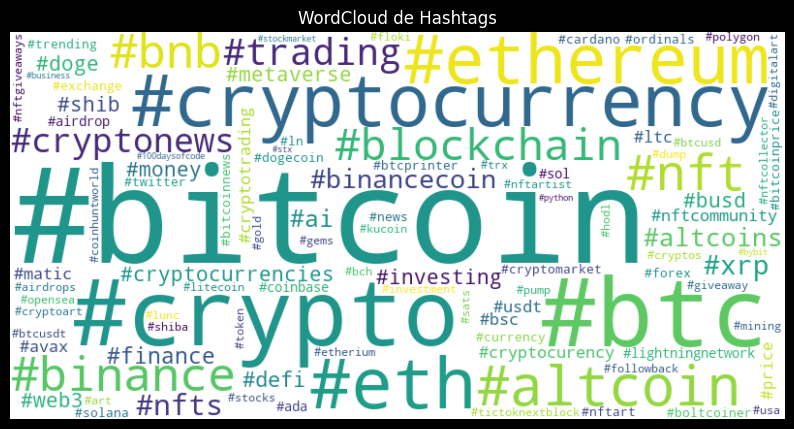

In [10]:
extractor.generate_hashtag_wordcloud(overall_df=hashtag_analysis['overall'])

## 6) Guardar resultados

In [11]:
# extractor.save_results()

In [12]:
extractor = DataExtractor()

df_api = extractor.load_data_api(
    query="bitcoin",
    max_results=20,
    output_file="data/tweets_from_api.csv"
)

df_api.head()

,tweet_id,user_name,date,text,lang,favorites,retweets,replies,views
0,2046667126157496348,0xChiefy,Tue Apr 21 19:07:22 +0000 2026,Bitcoin will repeat the same fractal we've see...,en,932,188,240,127022
1,2047753440369983734,Bitcoin_Teddy,Fri Apr 24 19:04:00 +0000 2026,A man snapped a selfie with Italy’s Prime Mini...,en,93,3,4,17997
2,2046828991248740472,naiivememe,Wed Apr 22 05:50:34 +0000 2026,when she knows you bought Bitcoin at 58K this ...,en,239,19,17,19021
3,2045162012062466418,naiivememe,Fri Apr 17 15:26:35 +0000 2026,POV : Bitcoin is pumping hard but you SOLD\nht...,en,163,11,7,36890
4,2045781172064858548,AshCrypto,Sun Apr 19 08:26:54 +0000 2026,Stocks are hitting new all time high while Bit...,en,811,87,188,50705
